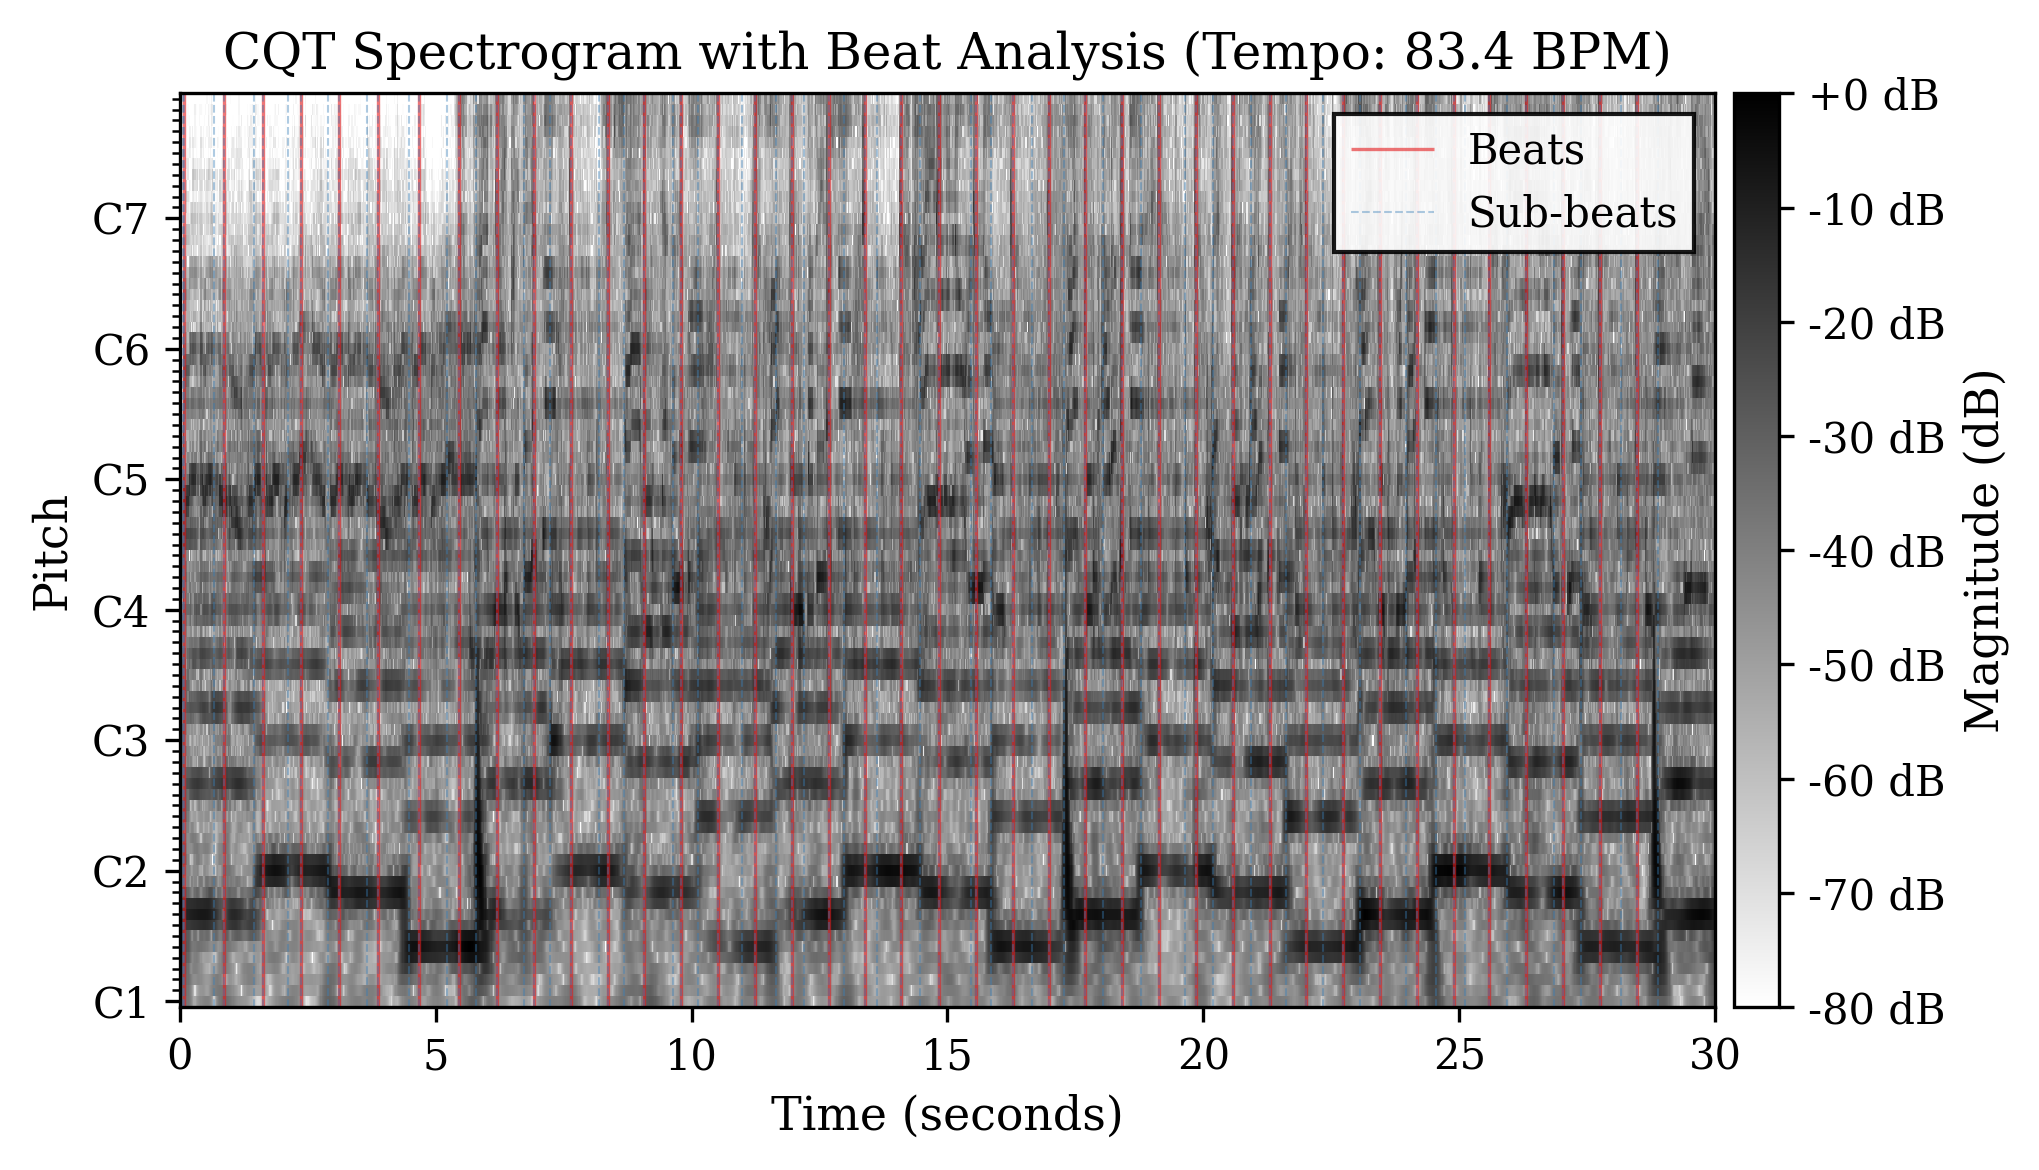

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
import matplotlib
from matplotlib.colors import LinearSegmentedColormap

# Set publication-quality parameters
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# 1. Load a segment of the song
song_id = "d28b5089-761c-456c-83df-499bb703ca39"
base_path = "../samples/suno_samples"
song = f"{base_path}/audio/{song_id}.mp3"

duration = 30  # 30 seconds for better visualization
y, sr = librosa.load(song, sr=22050, duration=duration)

# 2. Set consistent parameters for processing
hop_length = 512
fmin = 32.7  # C1 - setting a reasonable minimum frequency

# 3. Process the audio
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr, hop_length=hop_length)
beat_times = librosa.frames_to_time(beat_frames, sr=sr, hop_length=hop_length)

# 4. Calculate CQT with specific minimum frequency to avoid the white space
n_bins = 84  # 7 octaves of 12 semitones
bins_per_octave = 12
cqt = np.abs(librosa.cqt(y, sr=sr, hop_length=hop_length, fmin=fmin, 
                         n_bins=n_bins, bins_per_octave=bins_per_octave))

# 5. Generate sub-beats
subseg_frames = librosa.segment.subsegment(cqt, beat_frames, n_segments=2)
subseg_times = librosa.frames_to_time(subseg_frames, sr=sr, hop_length=hop_length)

# 6. Create a custom grayscale colormap with better contrast for publication
cmap = LinearSegmentedColormap.from_list('custom_gray', [(1, 1, 1), (0, 0, 0)], N=256)

# 7. Create figure with publication-friendly dimensions (based on IEEE column width)
fig, ax = plt.subplots(figsize=(7, 4))

# 8. Plot the spectrogram with improved parameters
img = librosa.display.specshow(
    librosa.amplitude_to_db(cqt, ref=np.max),
    y_axis='cqt_note',  # Show note names instead of Hz for musicological relevance
    x_axis='time',
    sr=sr,
    hop_length=hop_length,
    fmin=fmin,
    bins_per_octave=bins_per_octave,
    ax=ax,
    cmap=cmap
)

# 9. Set x-axis limits and proper tick spacing
ax.set_xlim(0, duration)
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))  # 5-second intervals

# 10. Plot the beats
ax.vlines(
    beat_times,
    0, 1,  # Use relative coordinates for y-axis
    color='#E41A1C',  # Publication-friendly red color
    alpha=0.6,
    linewidth=0.8,
    label='Beats',
    transform=ax.get_xaxis_transform()  # Use data-independent y coordinates
)

# 11. Plot the sub-beats
ax.vlines(
    subseg_times,
    0, 1,  # Use relative coordinates for y-axis
    color='#377EB8',  # Publication-friendly blue color
    linestyle='--',
    linewidth=0.5,
    alpha=0.4,
    label='Sub-beats',
    transform=ax.get_xaxis_transform()  # Use data-independent y coordinates
)

# 12. Add a professional legend in a non-obtrusive location
ax.legend(loc='upper right', framealpha=0.9, edgecolor='black', fancybox=False)

# 13. Add detailed but concise axis labels and title
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Pitch')
ax.set_title(f'CQT Spectrogram with Beat Analysis (Tempo: {tempo:.1f} BPM)')

# 14. Add a professional colorbar
cbar = plt.colorbar(img, ax=ax, format="%+2.0f dB", pad=0.01)
cbar.set_label('Magnitude (dB)')

# 15. Ensure tight layout with appropriate margins
plt.tight_layout()

# 17. Show the plot
plt.show()

Audio duration: 138.00 seconds
Chroma feature shape: (12, 11887)
Corresponding to 138.01 seconds
Found 20 segment boundaries
Boundary range: 0.00s to 132.25s


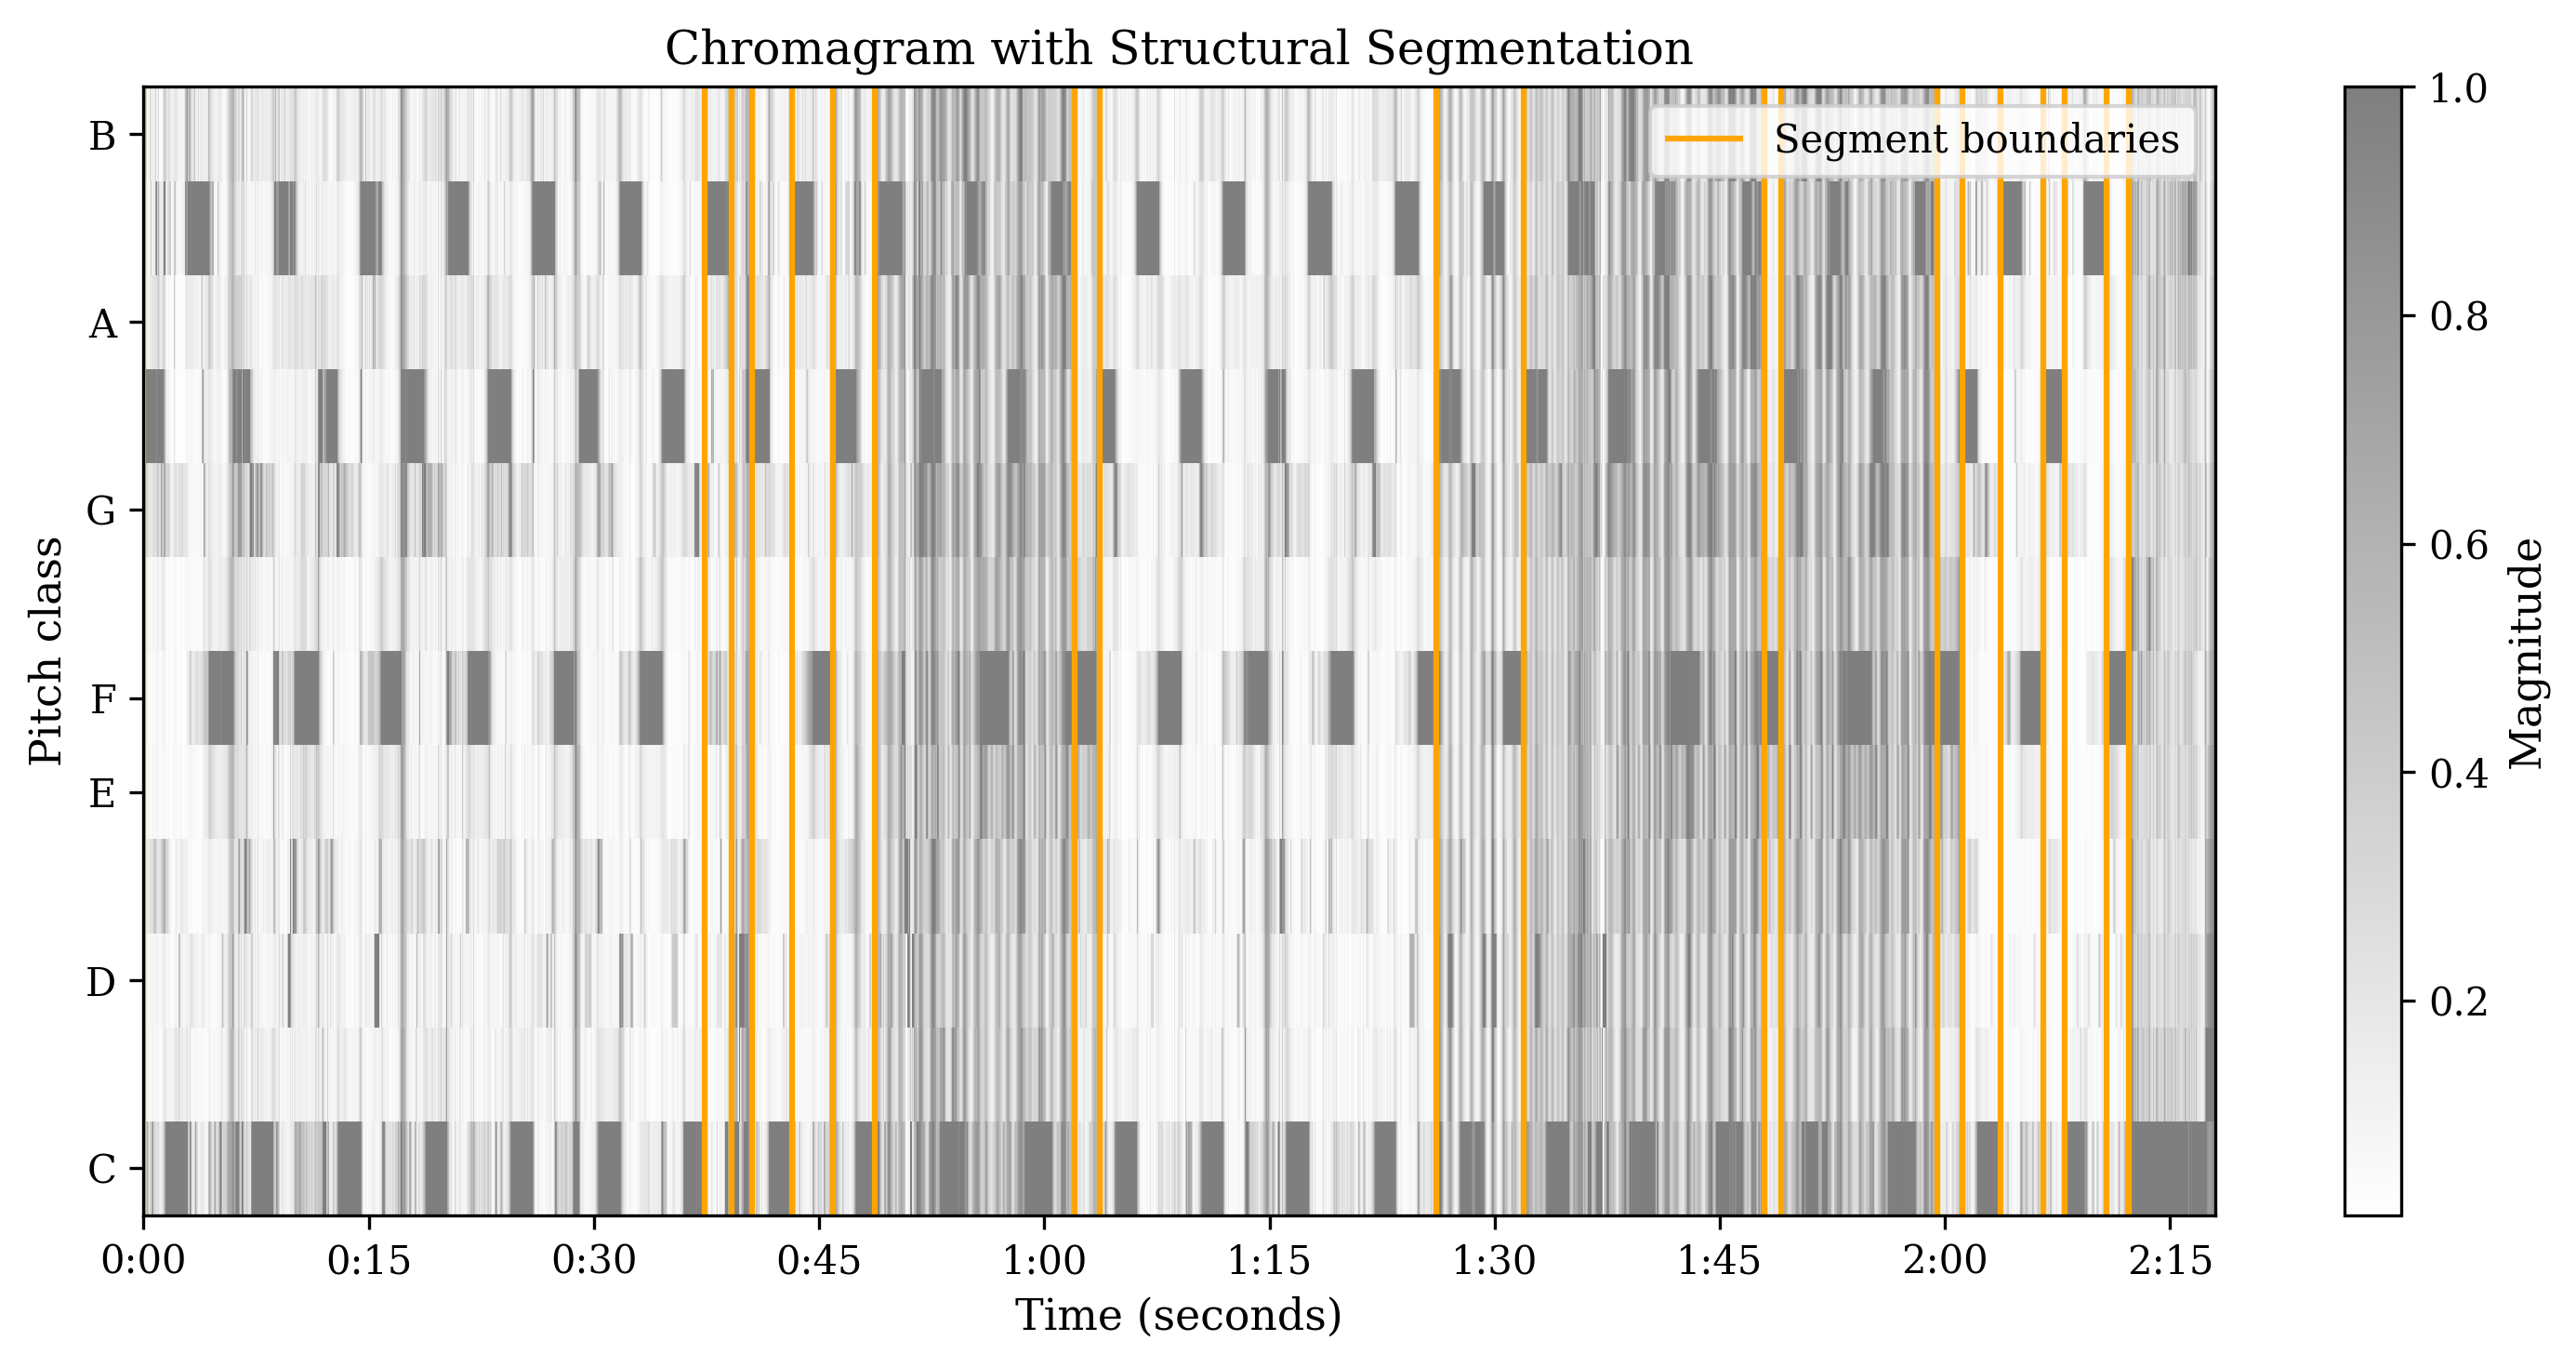

In [8]:
import matplotlib.pyplot as plt
import matplotlib.transforms as mpt
import librosa
import numpy as np
import matplotlib.colors as colors

# 1. Load the song
y, sr = librosa.load(song, sr=44100)

# 2. Get audio duration for reference
duration = librosa.get_duration(y=y, sr=sr)
print(f"Audio duration: {duration:.2f} seconds")

# 3. Use consistent hop_length across all processing
hop_length = 512

# 4. Compute chroma features with explicit hop_length
chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=hop_length)

# 5. Print feature dimensions for debugging
print(f"Chroma feature shape: {chroma.shape}")
print(f"Corresponding to {chroma.shape[1] * hop_length / sr:.2f} seconds")

# 6. Segmentation with consistent hop_length
bounds = librosa.segment.agglomerative(chroma, 20)
bound_times = librosa.frames_to_time(bounds, sr=sr, hop_length=hop_length)
print(f"Found {len(bound_times)} segment boundaries")
print(f"Boundary range: {bound_times[0]:.2f}s to {bound_times[-1]:.2f}s")

# 6. Create a publication-quality figure
plt.figure(figsize=(10, 5))
ax = plt.subplot(1, 1, 1)

# 7. Create blended transform for segment boundaries
trans = mpt.blended_transform_factory(ax.transData, ax.transAxes)

# 8. Create a custom colormap with alpha - FIXED APPROACH
# Create colormap data with built-in alpha
cmap_data = np.zeros((256, 4))
for i in range(256):
    # Create grayscale values (reversed: white to black)
    val = 1.0 - i/255
    cmap_data[i, 0] = val  # R
    cmap_data[i, 1] = val  # G
    cmap_data[i, 2] = val  # B
    cmap_data[i, 3] = 0.5  # Alpha (50%)

# Create the custom colormap from this data
gray_cmap_alpha = colors.ListedColormap(cmap_data)

# 9. Plot chroma features with explicit time axis and B&W colormap with alpha
img = librosa.display.specshow(
    chroma, 
    y_axis='chroma', 
    x_axis='time',
    sr=sr,
    hop_length=hop_length,
    ax=ax,
    cmap=gray_cmap_alpha
)

# 10. Explicitly set the x-axis limits to match audio duration
ax.set_xlim(0, duration)

# 11. Add segment boundaries with orange color
ax.vlines(
    bound_times, 
    0, 1, 
    color='orange',
    linestyle='-',
    linewidth=1.5,
    alpha=1.0,
    label='Segment boundaries',
    transform=trans
)

# 12. Add a colorbar and customize the plot
cbar = plt.colorbar(img, ax=ax)
cbar.set_label('Magnitude')
ax.legend(loc='upper right')
ax.set(title='Chromagram with Structural Segmentation')
ax.set_xlabel('Time (seconds)')

# 13. Make sure the figure is properly sized and displayed
plt.tight_layout()
plt.show()

Full song duration: 15.00 seconds
Detecting beats...
Computing CQT (this may take a moment)...
Creating visualization...
Displaying visualization...


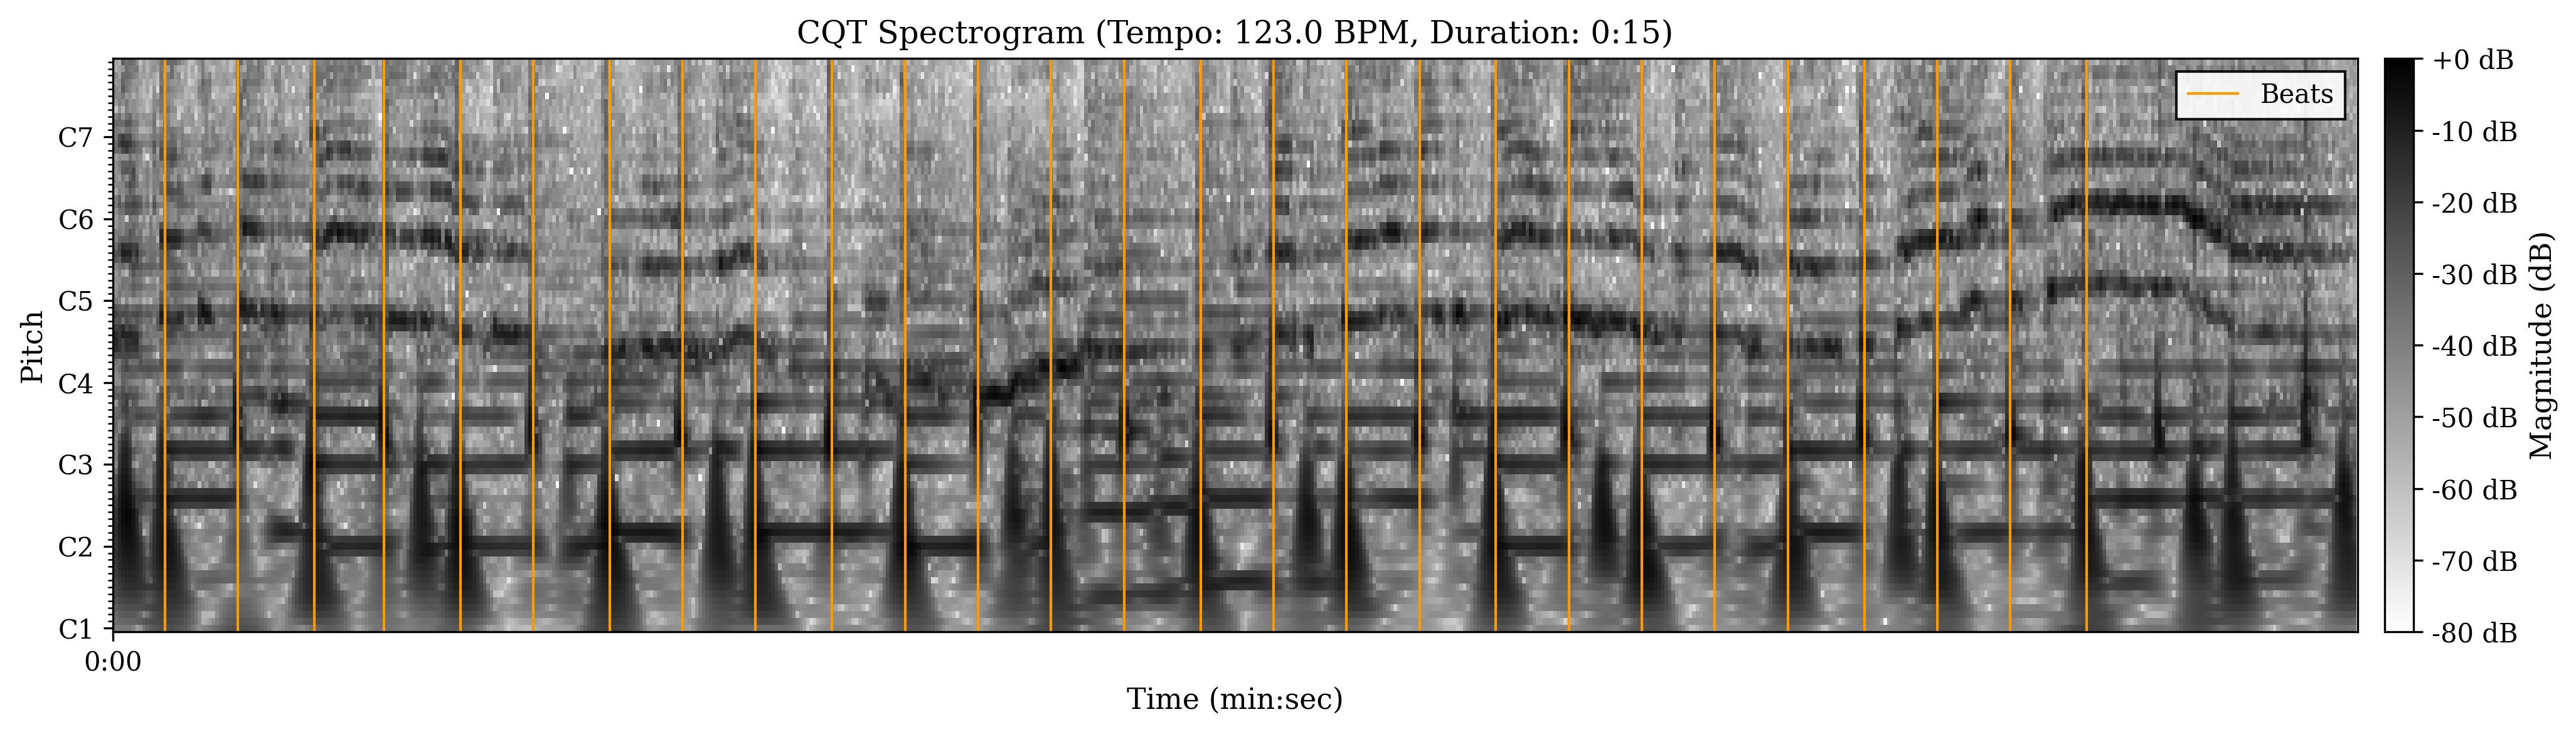

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
import matplotlib
from matplotlib.colors import LinearSegmentedColormap

# Set publication-quality parameters
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

duration = 15  # Duration for the analysis
# 1. Load the entire song
song = "../samples/suno_samples/audio/2cf8e9fb-f670-4223-89a8-d6bbb83887fd.mp3"
y, sr = librosa.load(song, sr=44100, duration=duration)

# 2. Use a larger hop_length for full-song processing (reduces computation and memory usage)
hop_length = 1024  # Larger hop_length for processing efficiency

# 3. Get song duration
duration = librosa.get_duration(y=y, sr=sr)
print(f"Full song duration: {duration:.2f} seconds")

# 4. Process the audio
print("Detecting beats...")
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr, hop_length=hop_length)
beat_times = librosa.frames_to_time(beat_frames, sr=sr, hop_length=hop_length)

# 5. Compute CQT with parameters optimized for full-song visualization
print("Computing CQT (this may take a moment)...")
fmin = 32.7  # C1
n_bins = 84  # 7 octaves
bins_per_octave = 12
cqt = np.abs(librosa.cqt(y, sr=sr, hop_length=hop_length, fmin=fmin, 
                        n_bins=n_bins, bins_per_octave=bins_per_octave))

# 6. Generate sub-beats if needed (you may skip this for full songs as it can get very dense)
# For full songs, sub-beats often make the visualization too cluttered, so consider skipping
# If you want them, uncomment:
# subseg_frames = librosa.segment.subsegment(cqt, beat_frames, n_segments=2)
# subseg_times = librosa.frames_to_time(subseg_frames, sr=sr, hop_length=hop_length)

# 7. Create a custom grayscale colormap
cmap = LinearSegmentedColormap.from_list('custom_gray', [(1, 1, 1), (0, 0, 0)], N=256)

# 8. Create figure with wider aspect ratio appropriate for full song
# Calculate width based on duration (longer songs need wider plots)
width = min(50, max(10, duration / 15))  # Width between 10-25 inches based on duration
fig, ax = plt.subplots(figsize=(15, 4))

# 9. Plot the spectrogram
print("Creating visualization...")
img = librosa.display.specshow(
    librosa.amplitude_to_db(cqt, ref=np.max),
    y_axis='cqt_note',
    x_axis='time',
    sr=sr,
    hop_length=hop_length,
    fmin=fmin,
    bins_per_octave=bins_per_octave,
    ax=ax,
    cmap=cmap
)

# 10. Customize x-axis for full song
ax.set_xlim(0, duration)
# Adjust tick spacing based on song length
minute_interval = max(1, int(duration / 60))  # At least 1-minute intervals
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(60 * minute_interval))
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
    lambda x, pos: f"{int(x // 60)}:{int(x % 60):02d}"  # Format as min:sec
))

# 11. Plot the beats (for full songs, reduce alpha to avoid visual clutter)
ax.vlines(
    beat_times,
    0, 1,
    color='#FF9900',  # Publication-friendly red color
    alpha=1,  # Lower alpha for full song visualization
    linewidth=1,
    label='Beats',
    transform=ax.get_xaxis_transform()
)

# 12. Plot sub-beats (optional, uncomment if needed)
# ax.vlines(
#     subseg_times,
#     0, 1,
#     color='#377EB8',
#     linestyle='--',
#     linewidth=0.4,
#     alpha=0.3,
#     label='Sub-beats',
#     transform=ax.get_xaxis_transform()
# )

# 13. Add professional legend, labels and title
ax.legend(loc='upper right', framealpha=0.9, edgecolor='black', fancybox=False)
ax.set_xlabel('Time (min:sec)')
ax.set_ylabel('Pitch')
ax.set_title(f'CQT Spectrogram (Tempo: {tempo:.1f} BPM, Duration: {int(duration//60)}:{int(duration%60):02d})')

# 14. Add a colorbar
cbar = plt.colorbar(img, ax=ax, format="%+2.0f dB", pad=0.01)
cbar.set_label('Magnitude (dB)')

# 15. Ensure tight layout
plt.tight_layout()

# 17. Show the plot
print("Displaying visualization...")
plt.show()